# Simple bifurcation example — shortest-path revision

This notebook is a revised version of the simple $\varepsilon$-attracting-basin example for the new terminal-state shortest-path algorithm.

Assumptions of the revised algorithm:

- every sequence has a terminal observation;
- every terminal observation is labelled `good` or `bad`;
- movement forward within the same sequence has cost `0`;
- movement backward within the same sequence is forbidden (`inf`);
- movement between different sequences uses the pairwise cost;
- ordinary $\varepsilon$ uses a minimax/bottleneck path cost;
- $\varepsilon_\Sigma$ uses an additive shortest-path cost.

The original iterative implementation in `epsbasin.py` is not used below.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

# Make the repository importable whether this notebook is launched from
# the repository root or from the examples directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "epsbasin").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import epsbasin
from epsbasin.shortest_path import (
    build_terminal_state_graph,
    eps_attracting_basin_shortest_path,
    eps_sum_attracting_basin_shortest_path,
)

# Optional out-of-sample evaluator added by cross_validation_query.patch.
# A mathematically equivalent fallback is defined below for environments where
# that patch has not yet been applied.
try:
    from epsbasin.shortest_path import minimum_epsilon_to_good_bad
except ImportError:
    minimum_epsilon_to_good_bad = None


## Generate the same type of two-branch time-series data

Only the last observation of each sequence is assigned `good` or `bad`. Intermediate observations are labelled `others`.

In [2]:
def hill_function(x, hill_coef=5, hill_half=2.0):
    x = np.asarray(x, dtype=float)
    return x**hill_coef / (hill_half**hill_coef + x**hill_coef)


def uniform_disk_noise(n, scale, rng):
    radius = scale * np.sqrt(rng.uniform(size=n))
    angle = rng.uniform(0.0, 2.0 * np.pi, size=n)
    return np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])


# Parameters
xlim = [0.0, 2.0]
xdiv = 20
scale = 5.0
hill_coef = 5
hill_half = 2.0
I = 20
noise_scale = 0.1
random_state = 0

rng = np.random.default_rng(random_state)
x = np.linspace(xlim[0], xlim[1], xdiv)
y = hill_function(x, hill_coef=hill_coef, hill_half=hill_half)

base_top = np.column_stack([x, y])
base_bottom = np.column_stack([x, -y])

sequences = []
seq_ids = []
branch_labels = []

seq_id = 0
for branch_name, base in [("top", base_top), ("bottom", base_bottom)]:
    for _ in range(I):
        seq = base + uniform_disk_noise(xdiv, noise_scale, rng)
        sequences.append(scale * seq)
        seq_ids.extend([seq_id] * xdiv)
        branch_labels.extend([branch_name] * xdiv)
        seq_id += 1

data_2d_flat = np.vstack(sequences)
seq_ids = np.asarray(seq_ids, dtype=int)
branch_labels = np.asarray(branch_labels, dtype=object)

cluster = np.full(data_2d_flat.shape[0], "others", dtype=object)
for sid in np.unique(seq_ids):
    idx = np.flatnonzero(seq_ids == sid)
    terminal = idx[-1]
    cluster[terminal] = "good" if data_2d_flat[terminal, 1] > 0 else "bad"

adata = ad.AnnData(X=data_2d_flat)
adata.obs = pd.DataFrame(
    {
        "seq_id": seq_ids,
        "cluster": cluster,
        "branch": branch_labels,
        "x": data_2d_flat[:, 0],
        "y": data_2d_flat[:, 1],
    },
    index=adata.obs_names.copy(),
)

adata


AnnData object with n_obs × n_vars = 800 × 2
    obs: 'seq_id', 'cluster', 'branch', 'x', 'y'

In [3]:
# Confirm that every sequence terminal is labelled good or bad.
terminal_rows = adata.obs.groupby("seq_id", sort=False).tail(1)
print(terminal_rows["cluster"].value_counts())
assert terminal_rows["cluster"].isin(["good", "bad"]).all()


cluster
good    20
bad     20
Name: count, dtype: int64


## Input trajectories

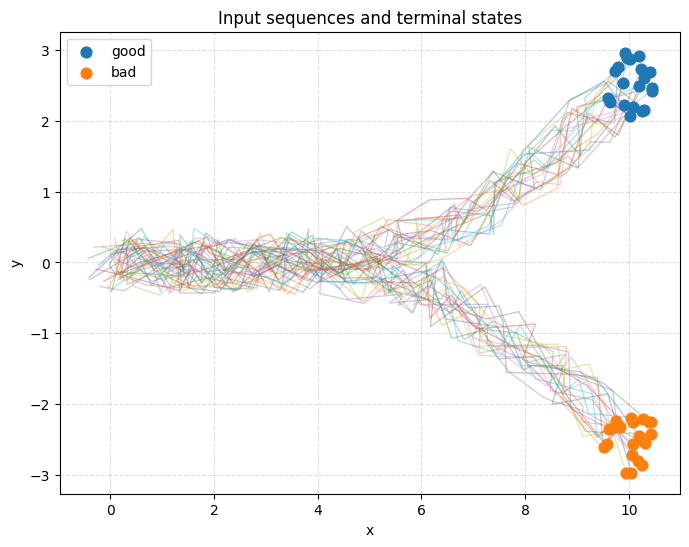

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    ax.plot(adata.X[idx, 0], adata.X[idx, 1], "-", lw=1, alpha=0.35)

mask_good = adata.obs["cluster"].to_numpy() == "good"
mask_bad = adata.obs["cluster"].to_numpy() == "bad"
ax.scatter(adata.X[mask_good, 0], adata.X[mask_good, 1], s=60, label="good", zorder=5)
ax.scatter(adata.X[mask_bad, 0], adata.X[mask_bad, 1], s=60, label="bad", zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Input sequences and terminal states")
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()


## Velocity vectors

The velocity is computed independently within each sequence by central differences, with one-sided differences at the endpoints.

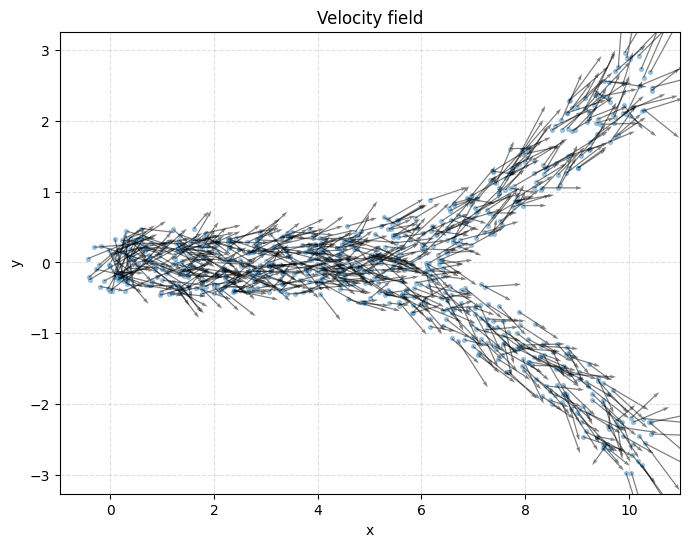

In [5]:
velocity = np.zeros_like(adata.X, dtype=float)

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    points = np.asarray(adata.X[idx], dtype=float)

    if len(idx) == 1:
        velocity[idx] = 0.0
    elif len(idx) == 2:
        v = points[1] - points[0]
        velocity[idx[0]] = v
        velocity[idx[1]] = v
    else:
        velocity[idx[0]] = points[1] - points[0]
        velocity[idx[-1]] = points[-1] - points[-2]
        velocity[idx[1:-1]] = 0.5 * (points[2:] - points[:-2])

adata.obsm["velocity"] = velocity

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata.X[:, 0], adata.X[:, 1], s=8, alpha=0.35)
ax.quiver(
    adata.X[:, 0],
    adata.X[:, 1],
    velocity[:, 0],
    velocity[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.002,
    alpha=0.5,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Velocity field")
ax.grid(ls="--", alpha=0.4)
plt.show()


## Build and inspect the directed weighted graph

`sequence_edge_mode="all_forward"` implements the requested rule that every forward pair in the same time series has weight zero, while the reverse direction is infinite.

In [6]:
graph = build_terminal_state_graph(
    adata,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    sequence_edge_mode="all_forward",
)

# Sanity check on one sequence.
idx0 = np.flatnonzero(adata.obs["seq_id"].to_numpy() == adata.obs["seq_id"].iloc[0])
print("forward first -> last:", graph.weights[idx0[0], idx0[-1]])
print("reverse last -> first:", graph.weights[idx0[-1], idx0[0]])
print("number of terminal states:", len(graph.terminal_indices))


forward first -> last: 0.0
reverse last -> first: inf
number of terminal states: 40


## New $\varepsilon$ debut functions: minimax shortest paths

For a path $P$, the path cost is

$$
\min_P \max_{e \in P} w(e).
$$

Good and Bad debut functions are computed together because every terminal state belongs to exactly one of the two terminal classes.

In [7]:
eps_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    output_key="eps_attracting_basin_sp",
    distance_key="eps_distance_sp",
    terminal_class_key="terminal_class",
    store_next_hop=True,
)

adata.obs[[
    "cluster",
    "terminal_class",
    "eps_attracting_basin_sp_good",
    "eps_attracting_basin_sp_bad",
    "eps_attracting_basin_sp_landscape",
]].head()


,cluster,terminal_class,eps_attracting_basin_sp_good,eps_attracting_basin_sp_bad,eps_attracting_basin_sp_landscape
0,others,good,-0.021629,0.021629,-0.021629
1,others,good,-0.021629,0.021629,-0.021629
2,others,good,-0.021629,0.021629,-0.021629
3,others,good,-0.021629,0.021629,-0.021629
4,others,good,-0.021629,0.021629,-0.021629


## New $\varepsilon_\Sigma$ debut functions: additive shortest paths

For a path $P$, the path cost is

$$
\min_P \sum_{e \in P} w(e).
$$

In [8]:
eps_sum_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    output_key="eps_sum_attracting_basin_sp",
    distance_key="eps_sum_distance_sp",
)

adata.obs[[
    "cluster",
    "eps_sum_attracting_basin_sp_good",
    "eps_sum_attracting_basin_sp_bad",
    "eps_sum_attracting_basin_sp_landscape",
]].head()


,cluster,eps_sum_attracting_basin_sp_good,eps_sum_attracting_basin_sp_bad,eps_sum_attracting_basin_sp_landscape
0,others,-0.021629,0.021629,-0.021629
1,others,-0.021629,0.021629,-0.021629
2,others,-0.021629,0.021629,-0.021629
3,others,-0.021629,0.021629,-0.021629
4,others,-0.021629,0.021629,-0.021629


## Debut functions for $\varepsilon$

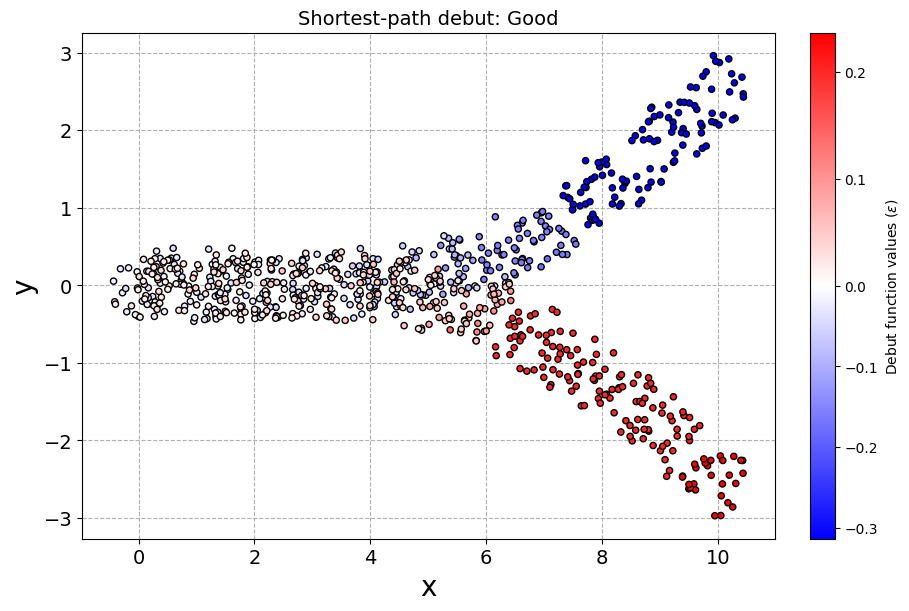

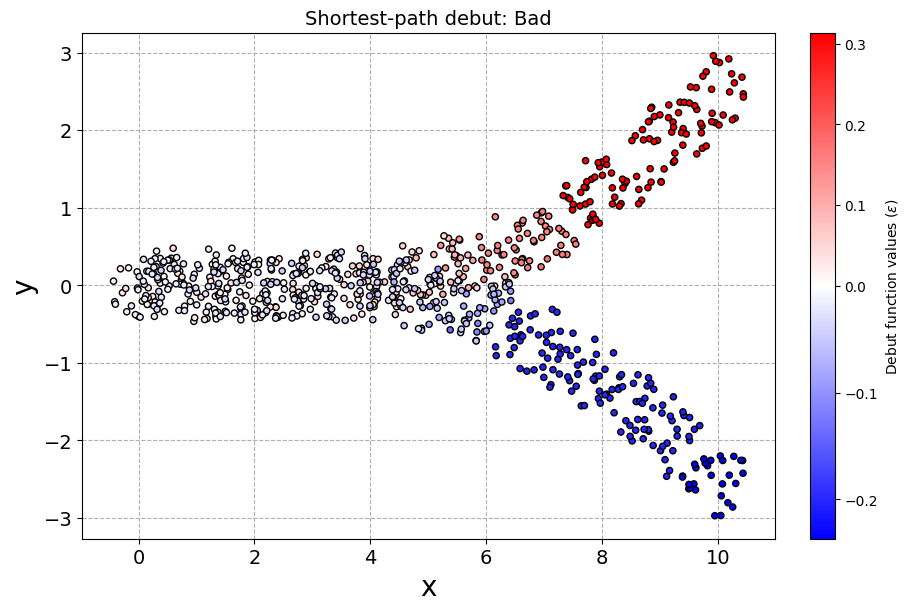

In [9]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="good",
    title="Shortest-path debut: Good",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="bad",
    title="Shortest-path debut: Bad",
)


## Debut functions for $\varepsilon_\Sigma$

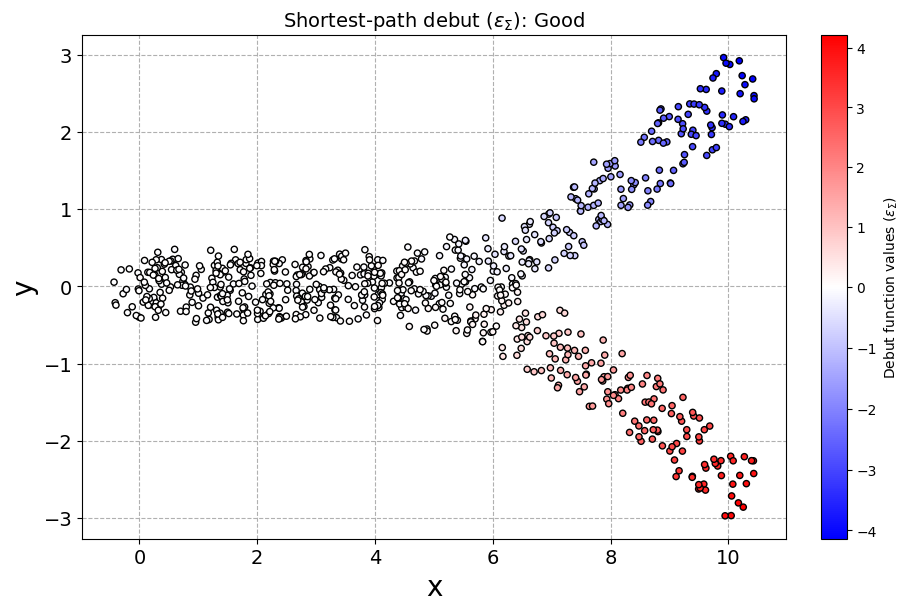

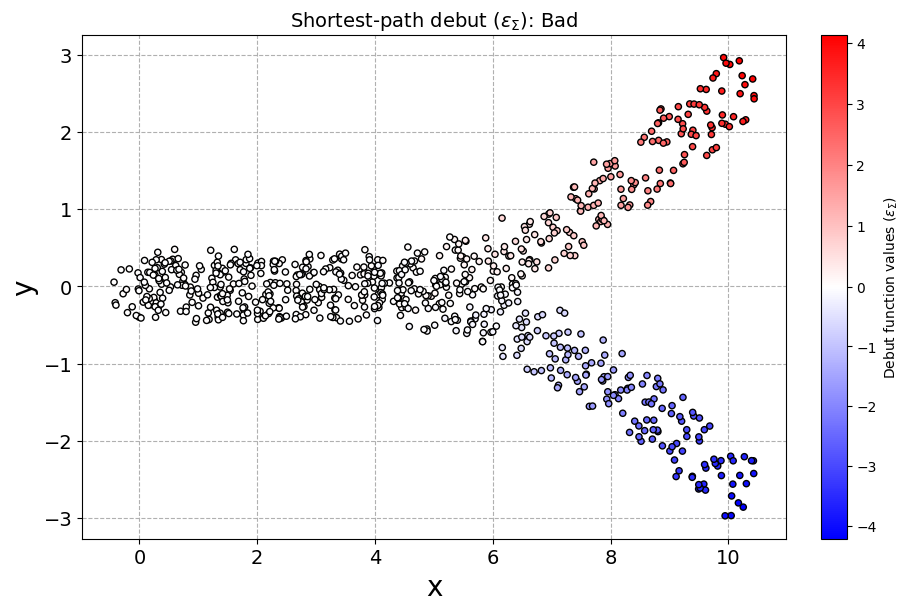

In [10]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="good",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): Good",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="bad",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): Bad",
)


## Landscape

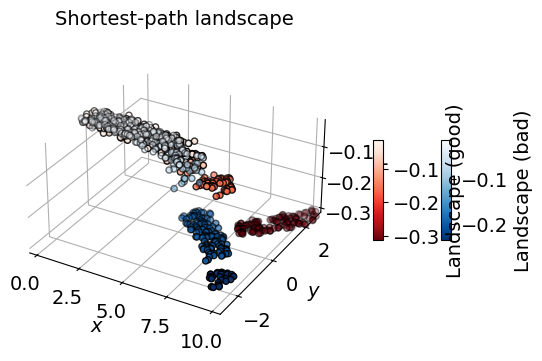

In [11]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title="Shortest-path landscape",
)


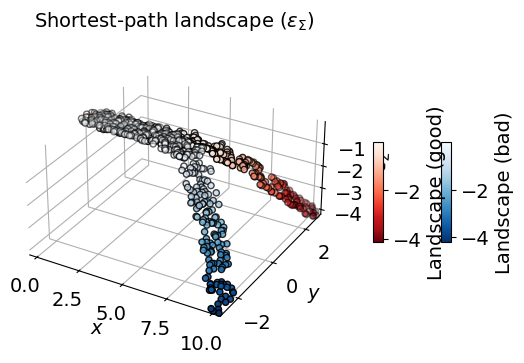

In [12]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title=r"Shortest-path landscape ($\varepsilon_\Sigma$)",
)


## Attracting-basin visualization at a selected threshold

The old plotting function can be reused because the new implementation writes Good/Bad debut functions using the same `<eps_key>_good` / `<eps_key>_bad` naming convention.

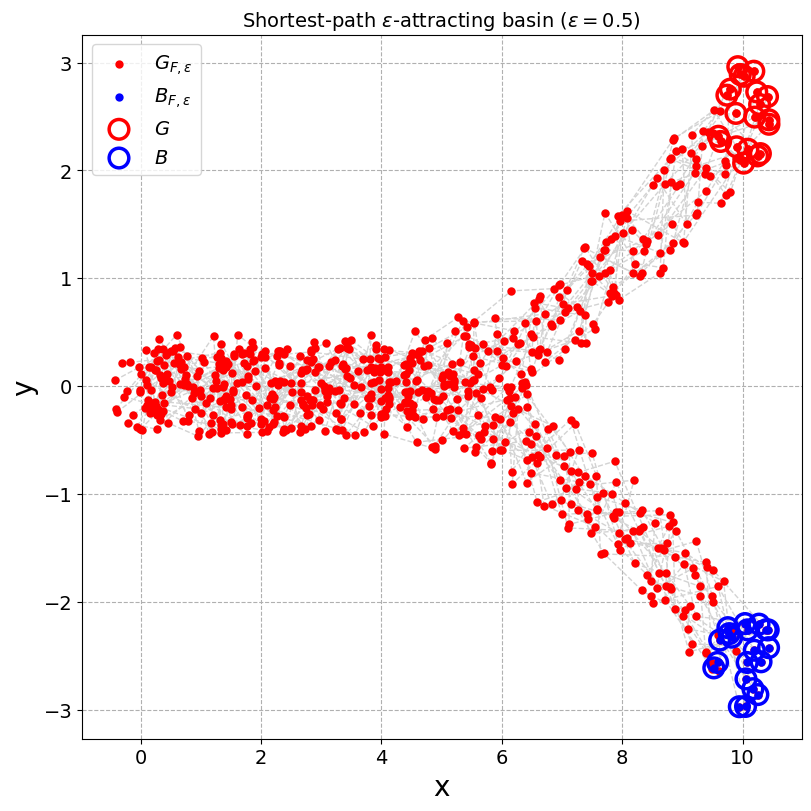

In [13]:
eps_threshold = 0.5

epsbasin.plot_attracting_basin(
    adata,
    eps_key="eps_attracting_basin_sp",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    eps_threshold=eps_threshold,
    figsize=(8, 8),
    title=rf"Shortest-path $\varepsilon$-attracting basin ($\varepsilon={eps_threshold}$)",
)


## Basic consistency checks

In [14]:
# Each observation inherits the natural terminal class of its own sequence.
for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    natural_terminal = adata.obs["cluster"].iloc[idx[-1]]
    assert np.all(adata.obs["terminal_class"].iloc[idx].to_numpy() == natural_terminal)

# The two signed debut functions are complementary under the Good/Bad terminal partition.
np.testing.assert_allclose(
    adata.obs["eps_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_attracting_basin_sp_bad"].to_numpy(),
)
np.testing.assert_allclose(
    adata.obs["eps_sum_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_sum_attracting_basin_sp_bad"].to_numpy(),
)

print("All consistency checks passed.")


All consistency checks passed.


## Leave-one-sequence-out cross-validation

This section performs **leave-one-sequence-out (LOSO) cross-validation**.
For each `seq_id`, the complete trajectory is removed from the training set.
The Good/Bad debut functions are reconstructed using only the remaining
trajectories.  Then every state $x$ in the held-out trajectory is connected to
the training graph using only the supplied costs $c(x, X_i)$.

For the ordinary $\varepsilon$ (bottleneck) case,

$$
\varepsilon_G(x)=\min_i\max\{c(x,X_i), d_G(X_i)\},\qquad
\varepsilon_B(x)=\min_i\max\{c(x,X_i), d_B(X_i)\}.
$$

The prediction is `good` when $\varepsilon_G(x)<\varepsilon_B(x)$ and `bad`
when the reverse inequality holds.  A tie is kept explicitly as `tie`.

The terminal label of the held-out sequence is used only as the test label; it
is never included in the training graph.

In [15]:
from dataclasses import dataclass


@dataclass(frozen=True)
class _ExternalStateEpsilonFallback:
    epsilon_good: float
    epsilon_bad: float
    entry_index_good: int
    entry_index_bad: int
    path_cost: str
    good_cluster_key: str
    bad_cluster_key: str


def _minimum_epsilon_to_good_bad_fallback(
    adata_train,
    x,
    costs,
    *,
    output_key="eps_attracting_basin_sp",
):
    """Notebook-local equivalent of minimum_epsilon_to_good_bad()."""
    params_key = f"{output_key}_params"
    if params_key not in adata_train.uns:
        raise KeyError(
            f"{params_key!r} is missing. Compute the shortest-path debut "
            "functions on the training data first."
        )

    params = adata_train.uns[params_key]
    path_cost = params["path_cost"]
    good_key = params.get("good_cluster_key", "good")
    bad_key = params.get("bad_cluster_key", "bad")

    x = np.asarray(x, dtype=float).reshape(-1)
    costs = np.asarray(costs, dtype=float).reshape(-1)

    if x.shape[0] != adata_train.X.shape[1]:
        raise ValueError("x has a different dimension from adata_train.X.")
    if costs.shape[0] != adata_train.n_obs:
        raise ValueError("costs must contain one value per training sample.")
    if np.isnan(costs).any() or np.any(costs[np.isfinite(costs)] < 0):
        raise ValueError("costs must be non-negative and may not contain NaN.")

    # Under the Good/Bad terminal partition, the non-negative distance to a
    # target class is the positive part of its signed debut function.
    d_good = np.maximum(
        adata_train.obs[f"{output_key}_{good_key}"].to_numpy(dtype=float),
        0.0,
    )
    d_bad = np.maximum(
        adata_train.obs[f"{output_key}_{bad_key}"].to_numpy(dtype=float),
        0.0,
    )

    if path_cost == "max":
        candidate_good = np.maximum(costs, d_good)
        candidate_bad = np.maximum(costs, d_bad)
    elif path_cost == "sum":
        candidate_good = costs + d_good
        candidate_bad = costs + d_bad
    else:
        raise ValueError(f"Unknown path_cost: {path_cost!r}")

    eps_good = float(np.min(candidate_good))
    eps_bad = float(np.min(candidate_bad))

    return _ExternalStateEpsilonFallback(
        epsilon_good=eps_good,
        epsilon_bad=eps_bad,
        entry_index_good=-1 if np.isinf(eps_good) else int(np.argmin(candidate_good)),
        entry_index_bad=-1 if np.isinf(eps_bad) else int(np.argmin(candidate_bad)),
        path_cost=path_cost,
        good_cluster_key=good_key,
        bad_cluster_key=bad_key,
    )


def evaluate_external_state(adata_train, x, costs, *, output_key):
    """Use the package function when available, otherwise use the fallback."""
    if minimum_epsilon_to_good_bad is not None:
        return minimum_epsilon_to_good_bad(
            adata_train,
            x,
            costs,
            output_key=output_key,
        )
    return _minimum_epsilon_to_good_bad_fallback(
        adata_train,
        x,
        costs,
        output_key=output_key,
    )


print(
    "Out-of-sample evaluator:",
    "epsbasin.shortest_path.minimum_epsilon_to_good_bad"
    if minimum_epsilon_to_good_bad is not None
    else "notebook fallback",
)

Out-of-sample evaluator: notebook fallback


In [16]:
def leave_one_sequence_out_cv(
    adata_full,
    *,
    path_cost="max",
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    tie_tol=1e-12,
    verbose=True,
):
    """Leave one complete trajectory out and predict every held-out state.

    Parameters
    ----------
    adata_full
        AnnData containing all trajectories.  Every trajectory terminal must be
        labelled Good or Bad.
    path_cost
        "max" for ordinary epsilon, "sum" for epsilon_Sigma.

    Returns
    -------
    pandas.DataFrame
        One row per held-out state with Good/Bad epsilon, prediction, margin,
        and the optimal first training vertex for each target class.
    """
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    seq_values = adata_full.obs[seq_key].to_numpy()
    all_indices = np.arange(adata_full.n_obs)
    seq_ids = list(pd.unique(seq_values))

    # The raw cost matrix is the cost between observations, before replacing
    # same-sequence forward edges by zero in the directed training graph.
    if cost_matrix_key in adata_full.uns:
        full_cost = np.asarray(adata_full.uns[cost_matrix_key], dtype=float)
    else:
        from sklearn.metrics import pairwise_distances
        full_cost = pairwise_distances(adata_full.X)

    if full_cost.shape != (adata_full.n_obs, adata_full.n_obs):
        raise ValueError("The full cost matrix has an incompatible shape.")

    rows = []

    for fold, heldout_seq in enumerate(seq_ids, start=1):
        test_indices = all_indices[seq_values == heldout_seq]
        train_indices = all_indices[seq_values != heldout_seq]

        # Entire held-out sequence, including its terminal label, is removed.
        adata_train = adata_full[train_indices].copy()
        adata_train.uns[cost_matrix_key] = full_cost[np.ix_(train_indices, train_indices)].copy()

        if path_cost == "max":
            output_key = "cv_eps_attracting_basin_sp"
            eps_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode=sequence_edge_mode,
                output_key=output_key,
            )
        else:
            output_key = "cv_eps_sum_attracting_basin_sp"
            eps_sum_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode=sequence_edge_mode,
                output_key=output_key,
            )

        # The held-out trajectory label is its terminal label.  This is only
        # consulted after fitting the training graph.
        true_label = str(adata_full.obs.iloc[test_indices[-1]][cluster_key])
        if true_label not in {good_cluster_key, bad_cluster_key}:
            raise ValueError(
                f"Held-out sequence {heldout_seq!r} does not terminate in "
                f"{good_cluster_key!r} or {bad_cluster_key!r}."
            )

        for step, global_index in enumerate(test_indices):
            x_query = np.asarray(adata_full.X[global_index], dtype=float).reshape(-1)
            costs_x_to_train = full_cost[global_index, train_indices]

            result = evaluate_external_state(
                adata_train,
                x_query,
                costs_x_to_train,
                output_key=output_key,
            )

            margin_good = result.epsilon_bad - result.epsilon_good
            if margin_good > tie_tol:
                prediction = good_cluster_key
            elif margin_good < -tie_tol:
                prediction = bad_cluster_key
            else:
                prediction = "tie"

            entry_good_local = result.entry_index_good
            entry_bad_local = result.entry_index_bad
            entry_good_global = (
                -1 if entry_good_local < 0 else int(train_indices[entry_good_local])
            )
            entry_bad_global = (
                -1 if entry_bad_local < 0 else int(train_indices[entry_bad_local])
            )

            rows.append(
                {
                    "path_cost": path_cost,
                    "seq_id": heldout_seq,
                    "step": step,
                    "fraction": 0.0 if len(test_indices) == 1 else step / (len(test_indices) - 1),
                    "global_index": int(global_index),
                    "x": float(adata_full.X[global_index, 0]),
                    "y": float(adata_full.X[global_index, 1]),
                    "true_label": true_label,
                    "epsilon_good": result.epsilon_good,
                    "epsilon_bad": result.epsilon_bad,
                    "margin_good": margin_good,
                    "prediction": prediction,
                    "correct": prediction == true_label,
                    "entry_good_global_index": entry_good_global,
                    "entry_bad_global_index": entry_bad_global,
                    "entry_good_seq_id": (
                        None if entry_good_global < 0
                        else adata_full.obs.iloc[entry_good_global][seq_key]
                    ),
                    "entry_bad_seq_id": (
                        None if entry_bad_global < 0
                        else adata_full.obs.iloc[entry_bad_global][seq_key]
                    ),
                }
            )

        if verbose:
            print(f"[{fold:02d}/{len(seq_ids):02d}] held out seq_id={heldout_seq!r}")

    return pd.DataFrame(rows)

### Run LOSO-CV for ordinary $\varepsilon$

This recomputes the training debut functions for every held-out trajectory, so
no state from the test trajectory is used to construct that fold's landscape.

In [17]:
cv_eps = leave_one_sequence_out_cv(
    adata,
    path_cost="max",
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    verbose=True,
)

cv_eps.head(10)

[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,path_cost,seq_id,step,fraction,global_index,x,y,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index,entry_good_seq_id,entry_bad_seq_id
0,max,0,0,0.000000,0,0.392749,0.070632,good,0.045768,0.045768,0.000000,tie,False,160,160,8,8
1,max,0,1,0.052632,1,0.710780,0.182812,good,0.043444,0.043444,0.000000,tie,False,101,101,5,5
2,max,0,2,0.105263,2,1.004222,-0.088817,good,0.059007,0.059007,0.000000,tie,False,782,782,39,39
3,max,0,3,0.157895,3,1.540252,-0.050838,good,0.021054,0.041222,0.020168,good,True,263,263,13,13
4,max,0,4,0.210526,4,1.767755,-0.296941,good,0.028956,0.021629,-0.007327,bad,False,503,503,25,25
5,max,0,5,0.263158,5,2.275895,0.325172,good,0.021947,0.021947,0.000000,tie,False,724,724,36,36
6,max,0,6,0.315789,6,3.547269,0.008826,good,0.104101,0.104101,0.000000,tie,False,187,187,9,9
7,max,0,7,0.368421,7,4.108171,-0.017590,good,0.057607,0.057607,0.000000,tie,False,628,628,31,31
8,max,0,8,0.421053,8,4.065269,-0.273527,good,0.030749,0.044773,0.014024,good,True,108,108,5,5
9,max,0,9,0.473684,9,4.453780,-0.275514,good,0.059292,0.059292,0.000000,tie,False,368,368,18,18


### Terminal-state prediction accuracy

The last state of each held-out trajectory is one independent terminal
prediction.  `accuracy_all` counts ties as incorrect; `accuracy_resolved`
reports accuracy only among non-tied predictions.

In [18]:
terminal_cv = (
    cv_eps.sort_values(["seq_id", "step"])
    .groupby("seq_id", sort=False)
    .tail(1)
    .reset_index(drop=True)
)

accuracy_all = terminal_cv["correct"].mean()
resolved = terminal_cv["prediction"] != "tie"
accuracy_resolved = (
    terminal_cv.loc[resolved, "correct"].mean() if resolved.any() else np.nan
)
tie_rate = (~resolved).mean()

print(f"terminal accuracy (ties incorrect): {accuracy_all:.3f}")
print(f"terminal accuracy (resolved only):  {accuracy_resolved:.3f}")
print(f"terminal tie rate:                  {tie_rate:.3f}")

display(terminal_cv[[
    "seq_id",
    "true_label",
    "epsilon_good",
    "epsilon_bad",
    "margin_good",
    "prediction",
    "correct",
]])

terminal accuracy (ties incorrect): 1.000
terminal accuracy (resolved only):  1.000
terminal tie rate:                  0.000


,seq_id,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct
0,0,good,0.079574,0.313776,0.234202,good,True
1,1,good,0.225839,0.313776,0.087937,good,True
2,2,good,0.150477,0.313776,0.163299,good,True
3,3,good,0.126064,0.313776,0.187713,good,True
4,4,good,0.060187,0.313776,0.253589,good,True
5,5,good,0.041265,0.327959,0.286694,good,True
6,6,good,0.041265,0.327604,0.286339,good,True
7,7,good,0.051427,0.313776,0.262350,good,True
8,8,good,0.066509,0.313776,0.247267,good,True
9,9,good,0.079574,0.313776,0.234202,good,True


### Score surfaces $S_p(x)=C_{B,p}(x)-C_{G,p}(x)$ on a background grid

Before looking at the time-resolved prediction accuracy, we evaluate the
landscape-derived score on a dense background grid in state space:

$$
S_p(x)=C_{B,p}(x)-C_{G,p}(x).
$$

Thus **larger values favor the Good outcome**, while smaller values favor Bad.

For the background-grid calculation, the code below now uses the **stored
non-negative shortest-path distances** directly, rather than recovering them
from the signed debut functions.  For a grid point $x$ and a training graph
vertex $x_i$,

$$
C_{A,\infty}(x)
=
\min_i \max\left\{d(x,x_i),D_{A,\infty}(x_i)\right\},
$$

whereas

$$
C_{A,1}(x)
=
\min_i \left\{d(x,x_i)+D_{A,1}(x_i)\right\}.
$$

This is important for $p=\infty$: the bottleneck score must use a **min-max**
extension, not an additive extension.

The $p=\infty$ and $p=1$ panels also use **independent display ranges**.
Their numerical magnitudes are not directly comparable, and a common color/z
range can make the $p=\infty$ surface appear artificially flat.

For validation, observed graph vertices are checked with the directed graph weights (not the raw Euclidean cost matrix), while arbitrary background states are checked against the external-state evaluator.

The thick black contour is the induced Good/Bad decision boundary

$$
S_p(x)=0.
$$

max: Bellman consistency error (Good, Bad)=(0.000e+00, 0.000e+00)
sum: Bellman consistency error (Good, Bad)=(0.000e+00, 0.000e+00)
max: background-query formula error (Good, Bad)=(0.000e+00, 0.000e+00)
sum: background-query formula error (Good, Bad)=(0.000e+00, 0.000e+00)
score ranges:
  p=infinity: [-0.2213, 0.3069]
  p=1:        [-4.2135, 4.1345]


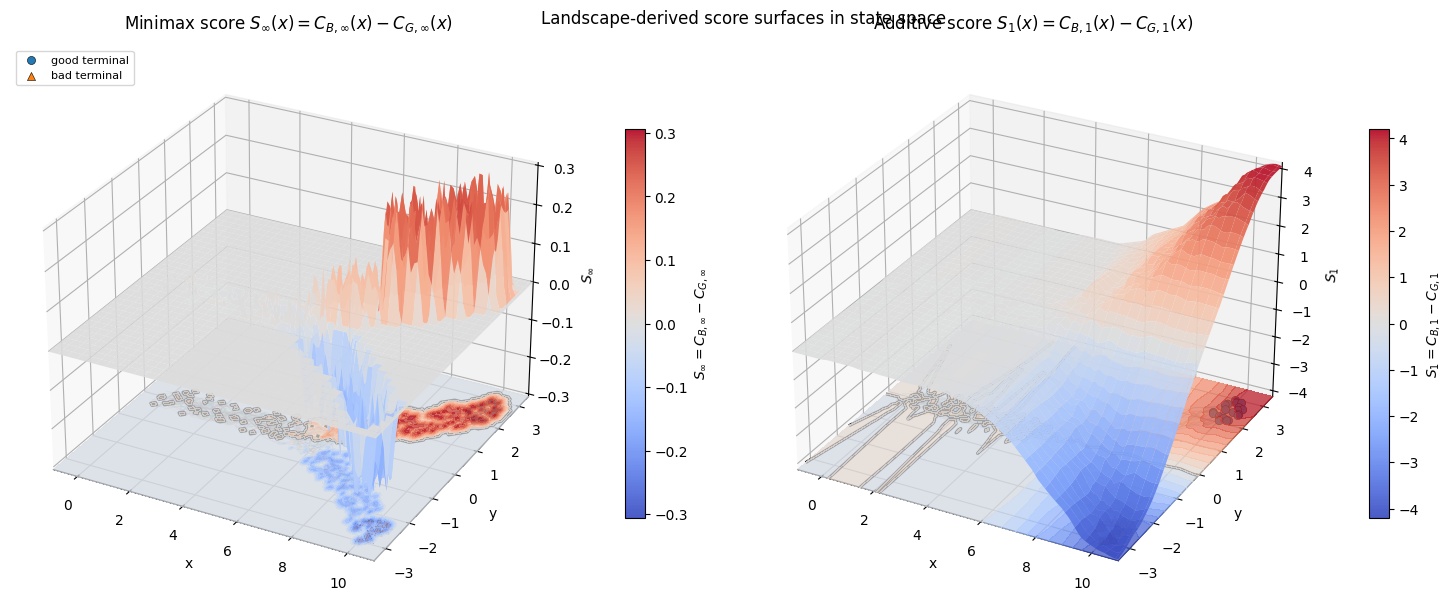

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SAVE_SCORE_SURFACE_FIGURES = False
SCORE_SURFACE_OUTPUT_DIR = Path("figures")
if SAVE_SCORE_SURFACE_FIGURES:
    SCORE_SURFACE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _finite_symmetric_limit(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 1.0

    limit = float(np.max(np.abs(finite)))
    if limit == 0.0:
        limit = 1.0
    return limit


def compute_score_surface_from_shortest_path_distances(
    adata_train,
    *,
    distance_good_key,
    distance_bad_key,
    path_cost,
    score_label,
    nx=101,
    ny=101,
    pad_x=0.5,
    pad_y=0.5,
    chunk_size=512,
):
    """
    Evaluate S_p(x)=C_B,p(x)-C_G,p(x) on a regular background grid.

    Parameters
    ----------
    path_cost
        "max" for p=infinity:
            C_A(x) = min_i max(d(x, x_i), D_A(x_i))
        "sum" for p=1:
            C_A(x) = min_i [d(x, x_i) + D_A(x_i)]

    Notes
    -----
    D_A(x_i) is read directly from the non-negative shortest-path distance
    columns created by epsbasin. This avoids any ambiguity from signed debut
    values when evaluating external/background states.
    """
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    for key in (distance_good_key, distance_bad_key):
        if key not in adata_train.obs.columns:
            raise KeyError(
                f"{key!r} is missing. Re-run the corresponding shortest-path "
                "calculation with distance_key set."
            )

    X_train = np.asarray(adata_train.X, dtype=float)
    distance_good = adata_train.obs[
        distance_good_key
    ].to_numpy(dtype=float)
    distance_bad = adata_train.obs[
        distance_bad_key
    ].to_numpy(dtype=float)

    if np.any(distance_good < 0) or np.any(distance_bad < 0):
        raise ValueError(
            "Stored shortest-path target distances must be non-negative."
        )

    x_min = float(X_train[:, 0].min()) - pad_x
    x_max = float(X_train[:, 0].max()) + pad_x
    y_min = float(X_train[:, 1].min()) - pad_y
    y_max = float(X_train[:, 1].max()) + pad_y

    x_grid = np.linspace(x_min, x_max, nx)
    y_grid = np.linspace(y_min, y_max, ny)
    XX, YY = np.meshgrid(x_grid, y_grid)
    grid_points = np.column_stack([XX.ravel(), YY.ravel()])

    cost_good = np.empty(grid_points.shape[0], dtype=float)
    cost_bad = np.empty(grid_points.shape[0], dtype=float)

    for start in range(0, grid_points.shape[0], chunk_size):
        stop = min(start + chunk_size, grid_points.shape[0])
        points = grid_points[start:stop]

        diff = points[:, None, :] - X_train[None, :, :]
        entry_cost = np.sqrt(np.sum(diff**2, axis=2))

        if path_cost == "max":
            # p = infinity: bottleneck / minimax extension.
            cost_good[start:stop] = np.min(
                np.maximum(
                    entry_cost,
                    distance_good[None, :],
                ),
                axis=1,
            )
            cost_bad[start:stop] = np.min(
                np.maximum(
                    entry_cost,
                    distance_bad[None, :],
                ),
                axis=1,
            )
        else:
            # p = 1: additive extension.
            cost_good[start:stop] = np.min(
                entry_cost + distance_good[None, :],
                axis=1,
            )
            cost_bad[start:stop] = np.min(
                entry_cost + distance_bad[None, :],
                axis=1,
            )

    score = cost_bad - cost_good

    return {
        "label": score_label,
        "path_cost": path_cost,
        "X": XX,
        "Y": YY,
        "score": score.reshape(YY.shape),
        "cost_good": cost_good.reshape(YY.shape),
        "cost_bad": cost_bad.reshape(YY.shape),
        "xlim": (x_min, x_max),
        "ylim": (y_min, y_max),
    }



def _extract_good_bad_costs(result):
    """
    Extract C_G and C_B from the external-state evaluator result.

    Both epsbasin.minimum_epsilon_to_good_bad() and the notebook fallback
    return an object with epsilon_good and epsilon_bad attributes.
    """
    if hasattr(result, "epsilon_good") and hasattr(result, "epsilon_bad"):
        return float(result.epsilon_good), float(result.epsilon_bad)

    if isinstance(result, dict):
        for good_key in ("epsilon_good", "cost_good", "good", "C_good"):
            if good_key in result:
                good_value = float(result[good_key])
                break
        else:
            good_value = None

        for bad_key in ("epsilon_bad", "cost_bad", "bad", "C_bad"):
            if bad_key in result:
                bad_value = float(result[bad_key])
                break
        else:
            bad_value = None

        if good_value is not None and bad_value is not None:
            return good_value, bad_value

    raise TypeError(
        "Could not extract Good/Bad costs from the external-state evaluator result."
    )


def validate_shortest_path_bellman_consistency(
    adata_train,
    *,
    distance_good_key,
    distance_bad_key,
    path_cost,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    atol=1e-10,
):
    """
    Validate the stored target distances using the ACTUAL directed graph edges.

    Important:
    ----------
    A raw Euclidean row is NOT the outgoing edge row of an observed trajectory
    state.  In the directed graph, same-sequence forward edges are free and
    backward edges are forbidden.  Therefore an observed graph vertex x_j must
    be checked with graph.weights[j, :], not with raw metric distances from x_j.

    The Bellman relation is

        D_A(j) = min_i max(w_ji, D_A(i))     for p = infinity,

    or

        D_A(j) = min_i [w_ji + D_A(i)]       for p = 1.
    """
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    graph = build_terminal_state_graph(
        adata_train,
        seq_key=seq_key,
        cluster_key=cluster_key,
        good_cluster_key=good_cluster_key,
        bad_cluster_key=bad_cluster_key,
        cost_matrix_key=cost_matrix_key,
        sequence_edge_mode=sequence_edge_mode,
    )
    weights = np.asarray(graph.weights, dtype=float)

    distance_good = adata_train.obs[
        distance_good_key
    ].to_numpy(dtype=float)
    distance_bad = adata_train.obs[
        distance_bad_key
    ].to_numpy(dtype=float)

    if path_cost == "max":
        recovered_good = np.min(
            np.maximum(
                weights,
                distance_good[None, :],
            ),
            axis=1,
        )
        recovered_bad = np.min(
            np.maximum(
                weights,
                distance_bad[None, :],
            ),
            axis=1,
        )
    else:
        recovered_good = np.min(
            weights + distance_good[None, :],
            axis=1,
        )
        recovered_bad = np.min(
            weights + distance_bad[None, :],
            axis=1,
        )

    good_error = float(
        np.nanmax(np.abs(recovered_good - distance_good))
    )
    bad_error = float(
        np.nanmax(np.abs(recovered_bad - distance_bad))
    )

    print(
        f"{path_cost}: Bellman consistency error "
        f"(Good, Bad)=({good_error:.3e}, {bad_error:.3e})"
    )

    if not (
        np.allclose(
            recovered_good,
            distance_good,
            atol=atol,
            rtol=0.0,
        )
        and np.allclose(
            recovered_bad,
            distance_bad,
            atol=atol,
            rtol=0.0,
        )
    ):
        raise AssertionError(
            f"The stored {path_cost!r} shortest-path distances do not satisfy "
            "the Bellman relation on the directed training graph."
        )


def validate_background_query_formula(
    adata_train,
    *,
    output_key,
    distance_good_key,
    distance_bad_key,
    path_cost,
    n_checks=12,
    random_state=0,
    atol=1e-10,
):
    """
    Check the formula used for arbitrary background states against the
    package/fallback external-state evaluator.

    A background state has no trajectory position, so its entry costs are the
    ordinary Euclidean distances to all training graph vertices.
    """
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    X_train = np.asarray(adata_train.X, dtype=float)
    distance_good = adata_train.obs[
        distance_good_key
    ].to_numpy(dtype=float)
    distance_bad = adata_train.obs[
        distance_bad_key
    ].to_numpy(dtype=float)

    rng = np.random.default_rng(random_state)
    low = X_train.min(axis=0) - 0.3
    high = X_train.max(axis=0) + 0.3
    query_points = rng.uniform(
        low=low,
        high=high,
        size=(n_checks, X_train.shape[1]),
    )

    max_good_error = 0.0
    max_bad_error = 0.0

    for point in query_points:
        entry_cost = np.linalg.norm(
            X_train - point[None, :],
            axis=1,
        )

        if path_cost == "max":
            direct_good = float(
                np.min(
                    np.maximum(
                        entry_cost,
                        distance_good,
                    )
                )
            )
            direct_bad = float(
                np.min(
                    np.maximum(
                        entry_cost,
                        distance_bad,
                    )
                )
            )
        else:
            direct_good = float(
                np.min(entry_cost + distance_good)
            )
            direct_bad = float(
                np.min(entry_cost + distance_bad)
            )

        result = evaluate_external_state(
            adata_train,
            point,
            entry_cost,
            output_key=output_key,
        )
        if hasattr(result, "epsilon_good") and hasattr(result, "epsilon_bad"):
            helper_good = float(result.epsilon_good)
            helper_bad = float(result.epsilon_bad)
        else:
            helper_good, helper_bad = _extract_good_bad_costs(result)

        max_good_error = max(
            max_good_error,
            abs(direct_good - helper_good),
        )
        max_bad_error = max(
            max_bad_error,
            abs(direct_bad - helper_bad),
        )

    print(
        f"{path_cost}: background-query formula error "
        f"(Good, Bad)=({max_good_error:.3e}, {max_bad_error:.3e})"
    )

    if (
        max_good_error > atol
        or max_bad_error > atol
    ):
        raise AssertionError(
            f"The explicit {path_cost!r} background-state formula does not "
            "match the external-state evaluator."
        )


def _terminal_points_from_adata(adata_obj):
    terminal_mask = adata_obj.obs[
        "cluster"
    ].isin(["good", "bad"]).to_numpy()
    terminal_points = np.asarray(
        adata_obj.X[terminal_mask],
        dtype=float,
    )
    terminal_cluster = adata_obj.obs.loc[
        terminal_mask,
        "cluster",
    ].to_numpy()
    return terminal_points, terminal_cluster


def _draw_trajectory_projection_3d(ax, z0):
    seq_values = adata.obs["seq_id"].to_numpy()

    for sid in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == sid)
        coords = np.asarray(adata.X[idx], dtype=float)
        ax.plot(
            coords[:, 0],
            coords[:, 1],
            zs=z0,
            zdir="z",
            lw=0.7,
            alpha=0.22,
        )

    terminal_points, terminal_cluster = (
        _terminal_points_from_adata(adata)
    )
    for label, marker in [("good", "o"), ("bad", "^")]:
        pts = terminal_points[
            terminal_cluster == label
        ]
        if pts.size:
            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                zs=np.full(pts.shape[0], z0),
                zdir="z",
                s=34,
                marker=marker,
                edgecolor="black",
                linewidth=0.4,
                label=f"{label} terminal",
                alpha=0.98,
            )


def plot_score_surface_3d(
    ax,
    surface,
    *,
    zlabel,
    vabs,
):
    """
    Draw one 3D score surface with its own numerical range.
    """
    Xg = surface["X"]
    Yg = surface["Y"]
    Zg = surface["score"]

    zmin = -vabs
    zmax = vabs
    levels = np.linspace(zmin, zmax, 21)

    surf = ax.plot_surface(
        Xg,
        Yg,
        Zg,
        cmap="coolwarm",
        vmin=zmin,
        vmax=zmax,
        linewidth=0,
        antialiased=True,
        alpha=0.92,
    )
    ax.contourf(
        Xg,
        Yg,
        Zg,
        zdir="z",
        offset=zmin,
        levels=levels,
        cmap="coolwarm",
        vmin=zmin,
        vmax=zmax,
        alpha=0.75,
    )
    ax.contour(
        Xg,
        Yg,
        Zg,
        zdir="z",
        offset=zmin,
        levels=[0.0],
        colors="black",
        linewidths=2.2,
    )

    _draw_trajectory_projection_3d(ax, zmin)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel(zlabel)
    ax.set_title(surface["label"], pad=12)
    ax.set_xlim(*surface["xlim"])
    ax.set_ylim(*surface["ylim"])
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=28, azim=-62)

    return surf


def _draw_trajectory_projection_2d(ax):
    seq_values = adata.obs["seq_id"].to_numpy()

    for sid in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == sid)
        coords = np.asarray(adata.X[idx], dtype=float)
        ax.plot(
            coords[:, 0],
            coords[:, 1],
            lw=0.8,
            alpha=0.25,
        )

    terminal_points, terminal_cluster = (
        _terminal_points_from_adata(adata)
    )
    for label, marker in [("good", "o"), ("bad", "^")]:
        pts = terminal_points[
            terminal_cluster == label
        ]
        if pts.size:
            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                s=28,
                marker=marker,
                edgecolor="black",
                linewidth=0.4,
                label=f"{label} terminal",
                alpha=0.98,
                zorder=4,
            )





# ------------------------------------------------------------------
# Validate the graph distances and the background-query formulas.
# ------------------------------------------------------------------
validate_shortest_path_bellman_consistency(
    adata,
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
)

validate_shortest_path_bellman_consistency(
    adata,
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
)

validate_background_query_formula(
    adata,
    output_key="eps_attracting_basin_sp",
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
)

validate_background_query_formula(
    adata,
    output_key="eps_sum_attracting_basin_sp",
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
)

# ------------------------------------------------------------------
# Compute S_infinity and S_1 explicitly from the stored distances.
# ------------------------------------------------------------------
surface_inf = compute_score_surface_from_shortest_path_distances(
    adata,
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
    score_label=(
        r"Minimax score $S_\infty(x)"
        r"=C_{B,\infty}(x)-C_{G,\infty}(x)$"
    ),
)

surface_one = compute_score_surface_from_shortest_path_distances(
    adata,
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
    score_label=(
        r"Additive score $S_1(x)"
        r"=C_{B,1}(x)-C_{G,1}(x)$"
    ),
)

# IMPORTANT:
# p=infinity and p=1 use independent display limits.
vabs_inf = _finite_symmetric_limit(surface_inf["score"])
vabs_one = _finite_symmetric_limit(surface_one["score"])

print(
    "score ranges:\n"
    f"  p=infinity: "
    f"[{np.nanmin(surface_inf['score']):.4f}, "
    f"{np.nanmax(surface_inf['score']):.4f}]\n"
    f"  p=1:        "
    f"[{np.nanmin(surface_one['score']):.4f}, "
    f"{np.nanmax(surface_one['score']):.4f}]"
)

# ------------------------------------------------------------------
# 1) 3D surfaces
# ------------------------------------------------------------------
fig = plt.figure(figsize=(15.0, 6.2))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

surf1 = plot_score_surface_3d(
    ax1,
    surface_inf,
    zlabel=r"$S_\infty$",
    vabs=vabs_inf,
)
surf2 = plot_score_surface_3d(
    ax2,
    surface_one,
    zlabel=r"$S_1$",
    vabs=vabs_one,
)

cbar1 = fig.colorbar(
    surf1,
    ax=ax1,
    shrink=0.70,
    pad=0.08,
)
cbar1.set_label(
    r"$S_\infty=C_{B,\infty}-C_{G,\infty}$"
)

cbar2 = fig.colorbar(
    surf2,
    ax=ax2,
    shrink=0.70,
    pad=0.08,
)
cbar2.set_label(
    r"$S_1=C_{B,1}-C_{G,1}$"
)

handles, labels = ax1.get_legend_handles_labels()
if handles:
    ax1.legend(
        handles,
        labels,
        loc="upper left",
        fontsize=8,
    )

fig.suptitle(
    "Landscape-derived score surfaces in state space",
    y=0.98,
)
fig.tight_layout()

if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_3d.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_3d.pdf",
        bbox_inches="tight",
    )

plt.show()


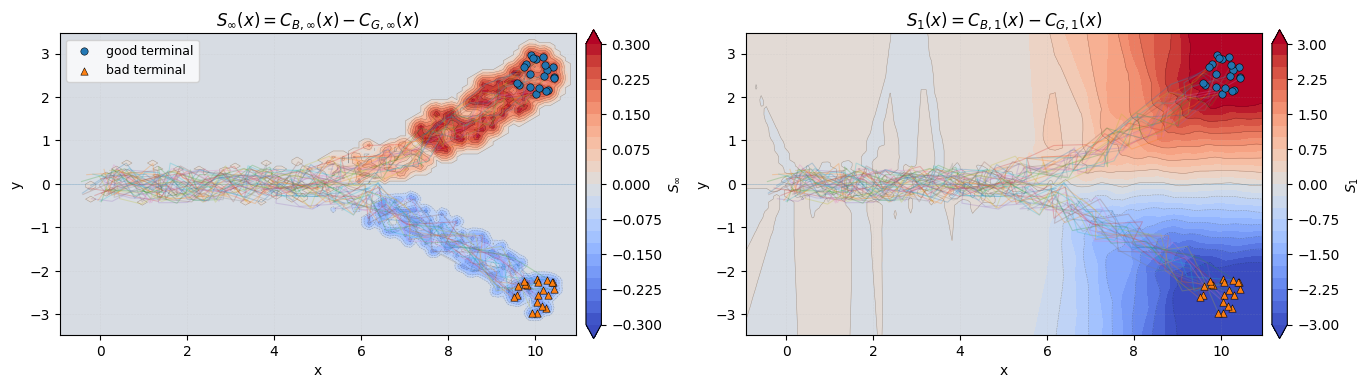

In [61]:
def plot_score_map(
    ax,
    surface,
    *,
    vabs,
    title,
    show_legend=False,
    emphasize_zero=True,
    nlevels=25,
    ):
    """
    Publication-oriented 2D heatmap + contour plot of S_p(x).
    """
    Xg = surface["X"]
    Yg = surface["Y"]
    Zg = surface["score"]

    levels = np.linspace(-vabs, vabs, nlevels)

    image = ax.contourf(
        Xg,
        Yg,
        Zg,
        levels=levels,
        cmap="coolwarm",
        vmin=-vabs,
        vmax=vabs,
        extend="both",
    )
    ax.contour(
        Xg,
        Yg,
        Zg,
        levels=levels[::2],
        colors="black",
        linewidths=0.35,
        alpha=0.30,
    )

    if emphasize_zero:
        ax.contour(
            Xg,
            Yg,
            Zg,
            levels=[0.0],
            colors="black",
            linewidths=2.4,
        )

    _draw_trajectory_projection_2d(ax)

    ax.axhline(0.0, lw=0.5, alpha=0.3)
    ax.set_xlim(*surface["xlim"])
    ax.set_ylim(*surface["ylim"])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(ls="--", lw=0.4, alpha=0.18)

    if show_legend:
        ax.legend(
            frameon=True,
            fontsize=9,
            loc="upper left",
        )

    return image
# ------------------------------------------------------------------
# 2) 2D heatmap + contour maps
# ------------------------------------------------------------------
vabs_inf = 0.3
vabs_one = 3

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.6, 5.7),
    constrained_layout=True,
)

im1 = plot_score_map(
    axes[0],
    surface_inf,
    vabs=vabs_inf,  # カラーバー範囲を少し広げる
    emphasize_zero=False,
    title=(
        r"$S_\infty(x)"
        r"=C_{B,\infty}(x)-C_{G,\infty}(x)$"
    ),
    show_legend=True,
)
im2 = plot_score_map(
    axes[1],
    surface_one,
    vabs=vabs_one,  # カラーバー範囲を少し広げる
    emphasize_zero=False,
    title=(
        r"$S_1(x)"
        r"=C_{B,1}(x)-C_{G,1}(x)$"
    ),
)

cbar1 = fig.colorbar(
    im1,
    ax=axes[0],
    shrink=0.55,
    pad=0.02,
)
cbar1.set_label(r"$S_\infty$")

cbar2 = fig.colorbar(
    im2,
    ax=axes[1],
    shrink=0.55,
    pad=0.02,
)
cbar2.set_label(r"$S_1$")

# fig.suptitle(
#     r"Score maps; thick black curve: $S_p(x)=0$",
#     y=1.02,
# )

if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_2d.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_2d.pdf",
        bbox_inches="tight",
    )

plt.show()


0.30689461334748735

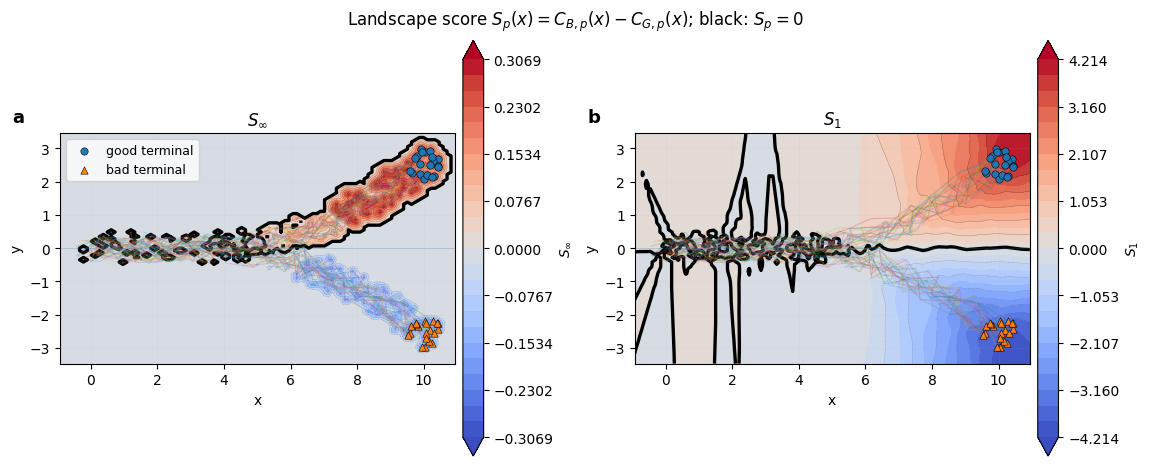

In [51]:

# ------------------------------------------------------------------
# 3) Publication-oriented compact figure
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.4, 4.6),
    constrained_layout=True,
)

im1 = plot_score_map(
    axes[0],
    surface_inf,
    vabs=vabs_inf,
    title=r"$S_\infty$",
    show_legend=True,
)
im2 = plot_score_map(
    axes[1],
    surface_one,
    vabs=vabs_one,
    title=r"$S_1$",
)

for ax, panel_label in zip(axes, ["a", "b"]):
    ax.text(
        -0.12,
        1.03,
        panel_label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="bottom",
    )

cbar1 = fig.colorbar(
    im1,
    ax=axes[0],
    shrink=0.92,
    pad=0.02,
)
cbar1.set_label(r"$S_\infty$")

cbar2 = fig.colorbar(
    im2,
    ax=axes[1],
    shrink=0.92,
    pad=0.02,
)
cbar2.set_label(r"$S_1$")

fig.suptitle(
    r"Landscape score $S_p(x)=C_{B,p}(x)-C_{G,p}(x)$; "
    r"black: $S_p=0$",
    y=1.02,
)

if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_publication.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_publication.pdf",
        bbox_inches="tight",
    )

plt.show()

### Prediction accuracy along the trajectory

This shows when the eventual terminal class becomes distinguishable as the
held-out trajectory progresses.

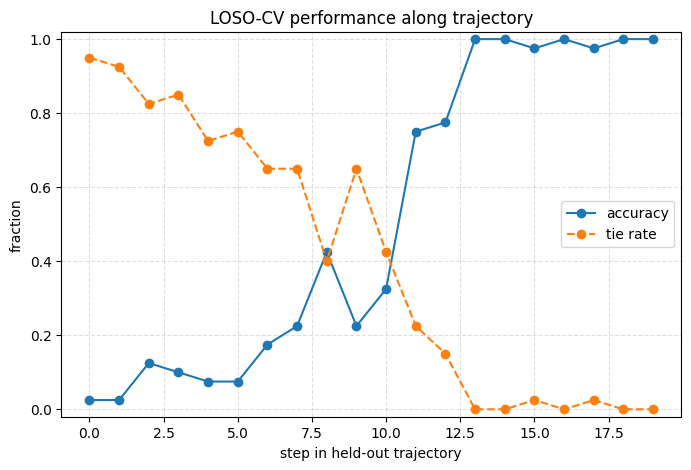

,step,accuracy,tie_rate,mean_fraction
0,0,0.025,0.950,0.000000
1,1,0.025,0.925,0.052632
2,2,0.125,0.825,0.105263
3,3,0.100,0.850,0.157895
4,4,0.075,0.725,0.210526
5,5,0.075,0.750,0.263158
6,6,0.175,0.650,0.315789
7,7,0.225,0.650,0.368421
8,8,0.425,0.400,0.421053
9,9,0.225,0.650,0.473684


In [20]:
accuracy_by_step = (
    cv_eps.groupby("step", as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        tie_rate=("prediction", lambda s: np.mean(s == "tie")),
        mean_fraction=("fraction", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(accuracy_by_step["step"], accuracy_by_step["accuracy"], "o-", label="accuracy")
ax.plot(accuracy_by_step["step"], accuracy_by_step["tie_rate"], "o--", label="tie rate")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("step in held-out trajectory")
ax.set_ylabel("fraction")
ax.set_title("LOSO-CV performance along trajectory")
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()

accuracy_by_step

### $\varepsilon_G$ and $\varepsilon_B$ for representative held-out trajectories

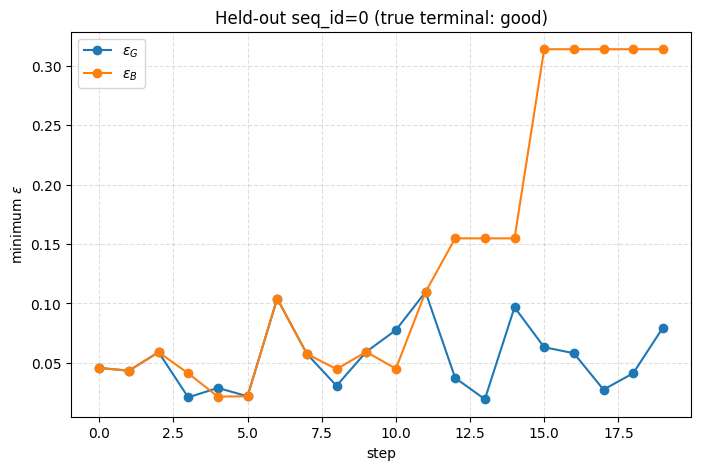

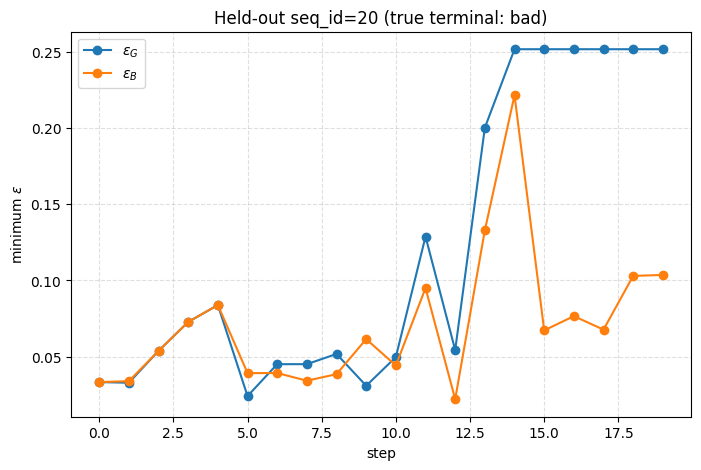

In [21]:
example_good_seq = terminal_cv.loc[
    terminal_cv["true_label"] == "good", "seq_id"
].iloc[0]
example_bad_seq = terminal_cv.loc[
    terminal_cv["true_label"] == "bad", "seq_id"
].iloc[0]

for sid in [example_good_seq, example_bad_seq]:
    df = cv_eps[cv_eps["seq_id"] == sid].sort_values("step")
    label = df["true_label"].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["epsilon_good"], "o-", label=r"$\varepsilon_G$")
    ax.plot(df["step"], df["epsilon_bad"], "o-", label=r"$\varepsilon_B$")
    ax.set_xlabel("step")
    ax.set_ylabel(r"minimum $\varepsilon$")
    ax.set_title(f"Held-out seq_id={sid} (true terminal: {label})")
    ax.grid(ls="--", alpha=0.4)
    ax.legend()
    plt.show()

### Cross-validated Good/Bad margin in state space

We define

$$
M(x)=\varepsilon_B(x)-\varepsilon_G(x).
$$

Positive values favor Good and negative values favor Bad.

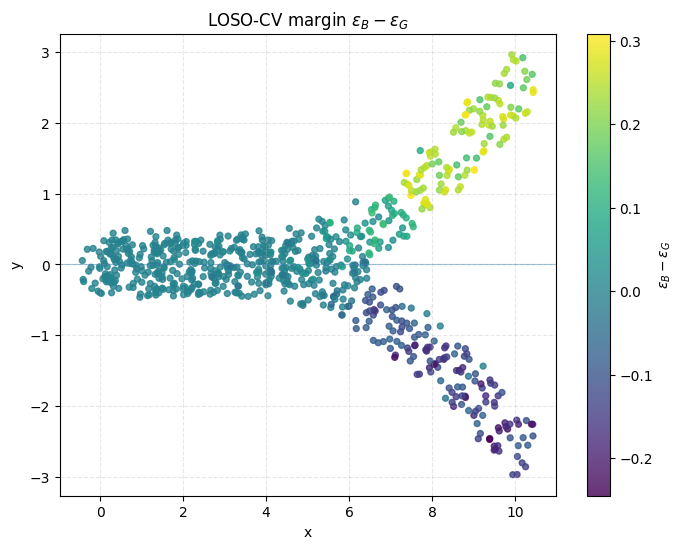

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    cv_eps["x"],
    cv_eps["y"],
    c=cv_eps["margin_good"],
    s=18,
    alpha=0.8,
)
ax.axhline(0.0, lw=0.8, alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"LOSO-CV margin $\varepsilon_B-\varepsilon_G$")
ax.grid(ls="--", alpha=0.3)
plt.colorbar(sc, ax=ax, label=r"$\varepsilon_B-\varepsilon_G$")
plt.show()

### Optional: LOSO-CV for $\varepsilon_\Sigma$

Set `RUN_EPS_SUM_CV = True` to repeat exactly the same cross-validation using
additive shortest-path costs.

In [23]:
RUN_EPS_SUM_CV = False

if RUN_EPS_SUM_CV:
    cv_eps_sum = leave_one_sequence_out_cv(
        adata,
        path_cost="sum",
        seq_key="seq_id",
        cluster_key="cluster",
        good_cluster_key="good",
        bad_cluster_key="bad",
        cost_matrix_key="cost_matrix",
        sequence_edge_mode="all_forward",
        verbose=True,
    )

    terminal_cv_sum = (
        cv_eps_sum.sort_values(["seq_id", "step"])
        .groupby("seq_id", sort=False)
        .tail(1)
    )
    print(
        "epsilon_Sigma terminal accuracy:",
        terminal_cv_sum["correct"].mean(),
    )
else:
    print("Set RUN_EPS_SUM_CV = True to run additive epsilon_Sigma LOSO-CV.")

Set RUN_EPS_SUM_CV = True to run additive epsilon_Sigma LOSO-CV.
